### VAD vs. ERA5 comparison figure generation

Jupyter notebook to plot VADs from radar sites and averaged meridional winds from ERA5 from specified region

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import netCDF4 as nc
import math
import pandas as pd
from netCDF4 import Dataset, num2date
import matplotlib.dates as mdates

### Helper Functions

In [ ]:

from datetime import timedelta

def round_to_nearest_five(dt):
    new_minute = 5 * round(dt.minute / 5)

    if new_minute == 60:
        new_minute = 0
        new_hour = dt.hour + 1

        # Handle midnight rollover correctly
        if new_hour == 24:
            new_hour = 0
            dt = dt + timedelta(days=1)

        dt = dt.replace(hour=new_hour, minute=new_minute, second=0, microsecond=0)
    else:
        dt = dt.replace(minute=new_minute, second=0, microsecond=0)

    return dt


# Time / grid helpers

LOCAL_OFFSET_HOURS = -5  # CDT = UTC - 5 h for Aug 2007

def to_local_time64(times):
    """Shift UTC times to local clock time for plotting only."""
    return np.array(times, dtype="datetime64[ns]") + np.timedelta64(LOCAL_OFFSET_HOURS, "h")

def to_dt64ns(times):
    """Convert datetime/cftime arrays to np.datetime64[ns] for matching/masking."""
    return np.array(times, dtype="datetime64[ns]")

def nearest_gridpoint(site_lat, site_lon, lat_arr, lon_arr):
    """Return nearest lat/lon index for 1-D ERA5 latitude and longitude arrays."""
    i = int(np.argmin(np.abs(lat_arr - site_lat)))
    j = int(np.argmin(np.abs(lon_arr - site_lon)))
    return i, j


In [3]:
# Import .nc files for VADs
KSHV = Dataset("/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/KSHVvad_ts.nc")
KFWS = Dataset("/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/KFWSvad_ts.nc")
KLCH = Dataset("/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/KLCHvad_ts.nc")

In [4]:
from netCDF4 import num2date

# Extract the time variable
time_KSHV = KSHV['time']

# Get the units and calendar attributes
time_units = time_KSHV.units  # e.g., "seconds since 2007-08-18 00:05:11"
time_calendar = time_KSHV.calendar  # e.g., "proleptic_gregorian"

# Convert the time variable to datetime objects
time_datetimes_KSHV = num2date(time_KSHV[:], units=time_units, calendar=time_calendar)

# Print the first few converted times
print(time_datetimes_KSHV[:5])

# Extract the time variable
time_KFWS = KFWS['time']
# Get the units and calendar attributes
time_units_KFWS = time_KFWS.units  # e.g., "seconds since 2007-08-18 00:05:11"
time_calendar = time_KFWS.calendar  # e.g., "proleptic_gregorian"
# Convert the time variable to datetime objects
time_datetimes_KFWS = num2date(time_KFWS[:], units=time_units_KFWS, calendar=time_calendar)
# Print the first few converted times
print(time_datetimes_KFWS[:5])

# Extract time variable
time_KLCH = KLCH['time']
time_units_KLCH = time_KLCH.units  # e.g., "seconds since 2007-08-18 00:05:11"
time_calendar = time_KLCH.calendar  # e.g., "proleptic_gregorian"
# Convert time variable to datetime objects
time_datetimes_KLCH = num2date(time_KLCH[:], units=time_units_KLCH, calendar=time_calendar)
# Print first few converted times
print(time_datetimes_KLCH[:5])


[cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 5, 11, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 11, 3, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 16, 57, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 22, 48, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 28, 42, 0, has_year_zero=True)]
[cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 4, 8, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 8, 59, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 13, 50, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 18, 41, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 23, 32, 0, has_year_zero=True)]
[cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 4, 44, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 10, 30, 0, has_year_zero=True)
 cftime.DatetimeProl

In [5]:
#PRint time units
print(time_units)
print(time_units_KFWS)
print(time_units_KLCH)

seconds since 2007-08-18 00:05:11
seconds since 2007-08-18 00:04:08
seconds since 2007-08-18


In [6]:
# Apply rounding to both datasets
rounded_times_KSHV = np.array([round_to_nearest_five(dt) for dt in time_datetimes_KSHV])
rounded_times_KFWS = np.array([round_to_nearest_five(dt) for dt in time_datetimes_KFWS])
rounded_times_KLCH = np.array([round_to_nearest_five(dt) for dt in time_datetimes_KLCH])

In [7]:
print("KSHV units:", KSHV['time'].units)
print("KLCH units:", KLCH['time'].units)

print("KLCH first 3 times before rounding:", time_datetimes_KLCH[:3])
print("KLCH first 3 times after rounding:", [round_to_nearest_five(t) for t in time_datetimes_KLCH[:3]])


KSHV units: seconds since 2007-08-18 00:05:11
KLCH units: seconds since 2007-08-18
KLCH first 3 times before rounding: [cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 4, 44, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 10, 30, 0, has_year_zero=True)
 cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 16, 15, 0, has_year_zero=True)]
KLCH first 3 times after rounding: [cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 5, 0, 0, has_year_zero=True), cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 10, 0, 0, has_year_zero=True), cftime.DatetimeProlepticGregorian(2007, 8, 18, 0, 15, 0, 0, has_year_zero=True)]


In [8]:
v_KSHV = KSHV['v'][:]
v_KFWS = KFWS['v'][:]
v_KLCH = KLCH['v'][:]
h_KSHV = KSHV['height'][:]
h_KFWS = KFWS['height'][:]
h_KLCH = KLCH['height'][:]


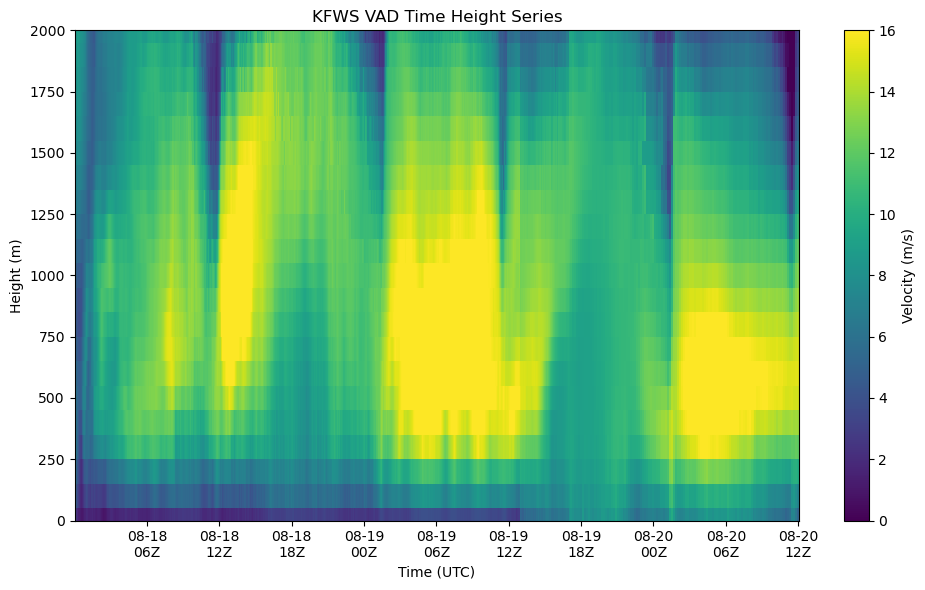

In [9]:
# Convert datetime objects to matplotlib's numeric date format
time_KFWS = mdates.date2num(time_datetimes_KFWS)
#Plot time height series of k_KFWS to check
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(111)
v_KFWS_plot = ax1.pcolormesh(time_KFWS, h_KFWS, v_KFWS.T, cmap='viridis', vmin=0, vmax=16)
ax1.set_ylim(0, 2000)
ax1.set_title('KFWS VAD Time Height Series')
ax1.set_ylabel('Height (m)')
ax1.set_xlabel('Time (UTC)')
# Format the x-axis to display time as MM-DD HH:MM UTC
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%HZ"))
fig.colorbar(v_KFWS_plot, ax=ax1, label='Velocity (m/s)')
plt.tight_layout()
plt.show()

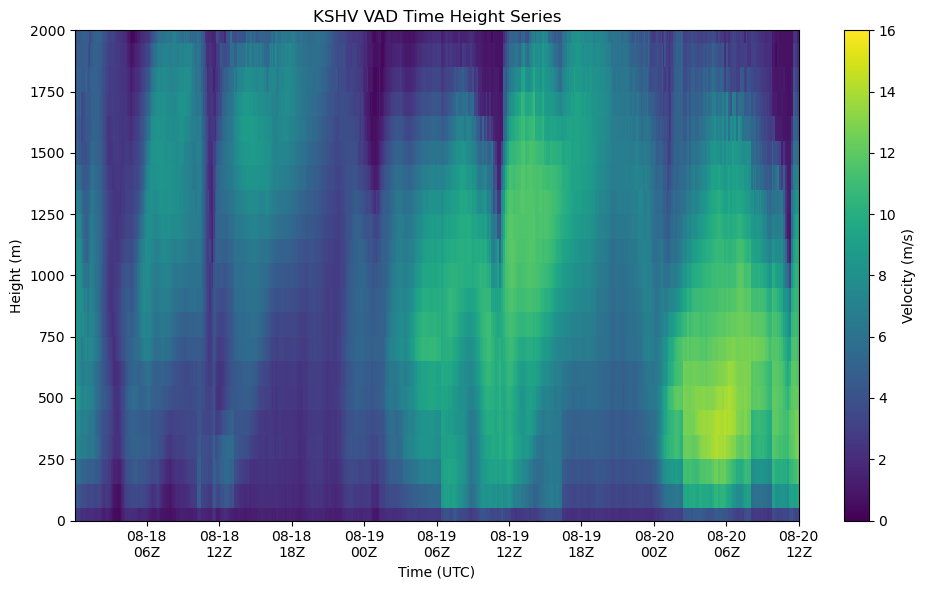

In [11]:
#Same for KSHV
time_KSHV = mdates.date2num(time_datetimes_KSHV)
#Plot time height series of k_KSHV to check
fig = plt.figure(figsize=(10, 6))
ax2 = fig.add_subplot(111)
v_KSHV_plot = ax2.pcolormesh(time_KSHV, h_KSHV, v_KSHV.T, cmap='viridis', vmin=0, vmax=16)
ax2.set_ylim(0, 2000)
ax2.set_title('KSHV VAD Time Height Series')
ax2.set_ylabel('Height (m)')
ax2.set_xlabel('Time (UTC)')
# Format the x-axis to display time as MM-DD HH:MM UTC
ax2.xaxis_date()
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%HZ"))
fig.colorbar(v_KSHV_plot, ax=ax2, label='Velocity (m/s)')
plt.tight_layout()
plt.show()

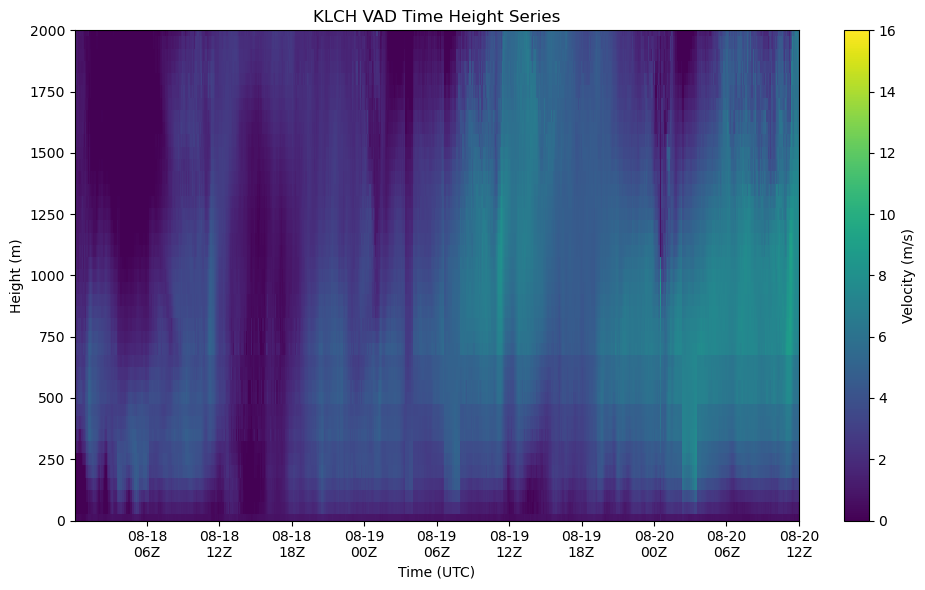

In [12]:
# Same for KLCH
time_KLCH = mdates.date2num(time_datetimes_KLCH)
#Plot time height series of k_KLCH to check
fig = plt.figure(figsize=(10, 6))
ax3 = fig.add_subplot(111)
v_KLCH_plot = ax3.pcolormesh(time_KLCH, h_KLCH, v_KLCH.T, cmap='viridis', vmin=0, vmax=16)
ax3.set_ylim(0, 2000)
ax3.set_title('KLCH VAD Time Height Series')
ax3.set_ylabel('Height (m)')
ax3.set_xlabel('Time (UTC)')
# Format the x-axis to display time as MM-DD HH:MM UTC
ax3.xaxis_date()
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%HZ"))
fig.colorbar(v_KLCH_plot, ax=ax3, label='Velocity (m/s)')
plt.tight_layout()
plt.show()


In [15]:

# Define a common height grid (0–2000 m every 100 m)
h_common = np.arange(0, 2000 + 0.1, 100)

# Convert rounded VAD times to a common dtype before intersecting.
# This fixes the common_times issue and ensures the VAD average uses all 3 sites.
rounded_times_KSHV_np = to_dt64ns(rounded_times_KSHV)
rounded_times_KFWS_np = to_dt64ns(rounded_times_KFWS)
rounded_times_KLCH_np = to_dt64ns(rounded_times_KLCH)

common_times = np.intersect1d(rounded_times_KSHV_np, rounded_times_KFWS_np)
common_times = np.intersect1d(common_times, rounded_times_KLCH_np)

vad_avg = []
avg_times = []

for t in common_times:
    idx1 = np.where(rounded_times_KSHV_np == t)[0]
    idx2 = np.where(rounded_times_KFWS_np == t)[0]
    idx3 = np.where(rounded_times_KLCH_np == t)[0]

    if idx1.size > 0 and idx2.size > 0 and idx3.size > 0:
        # Extract v-wind profiles
        v1 = v_KSHV[idx1[0], :]
        v2 = v_KFWS[idx2[0], :]
        v3 = v_KLCH[idx3[0], :]

        # Interpolate all three VADs to the same height grid
        v1_interp = np.interp(h_common, h_KSHV, v1)
        v2_interp = np.interp(h_common, h_KFWS, v2)
        v3_interp = np.interp(h_common, h_KLCH, v3)

        # Average across all three VADs
        avg = np.nanmean(np.vstack([v1_interp, v2_interp, v3_interp]), axis=0)
        vad_avg.append(avg)
        avg_times.append(t)

vad_avg = np.array(vad_avg)
common_times = np.array(avg_times, dtype="datetime64[ns]")

print("Common VAD times:", len(common_times))
print("Three-site VAD average shape:", vad_avg.shape)


Common VAD times: 371
Three-site VAD average shape: (371, 21)


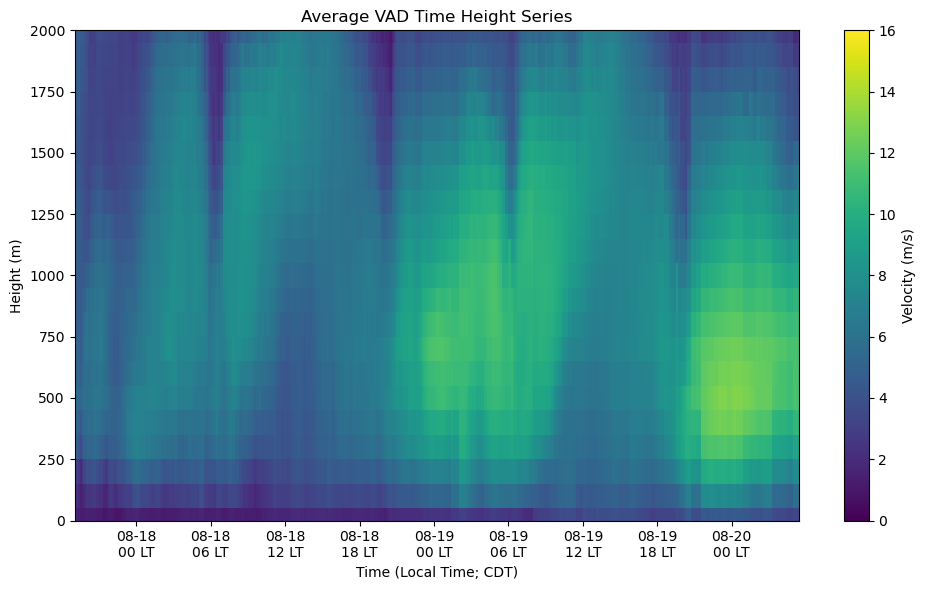

In [16]:

#Plot average of VADs
# Convert common_times to matplotlib's numeric date format after shifting to local time
common_times_num = mdates.date2num(to_local_time64(common_times))
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
vad_avg_plot = ax.pcolormesh(common_times_num, h_common, vad_avg.T, cmap='viridis', vmin=0, vmax=16)
ax.set_ylim(0, 2000)
ax.set_title('Average VAD Time Height Series')
ax.set_ylabel('Height (m)')
ax.set_xlabel('Time (Local Time; CDT)')
# Format the x-axis to display time as MM-DD HH local time
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H LT"))
fig.colorbar(vad_avg_plot, ax=ax, label='Velocity (m/s)')
plt.tight_layout()
plt.show()


In [17]:
#Import ERA5 data
ds = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/ERA5erinLLJvar.nc')
sfc = Dataset('/ourdisk/hpc/radclouds/auto_archive_notyet/tape_2copies/tc_erin/analysis/ERA5erinsfc.nc')

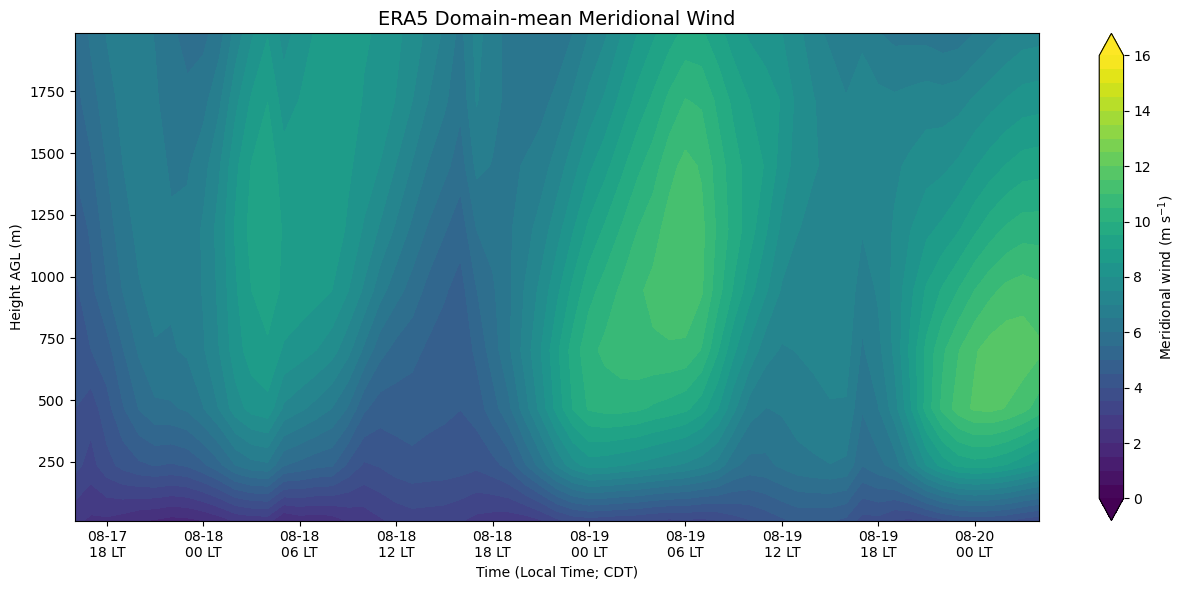

In [ ]:
radar_sites = {
    "KSHV": (32.45, -93.83),
    "KFWS": (32.57, -97.30),
    "KLCH": (30.13, -93.23)
}
# a small box that encloses the three radars (for domain mean)
levels_of_interest = [1000, 975, 950, 925, 900, 875, 850, 825, 800]
 ------------------

time     = ds.variables["valid_time"][:]    # hours since...
time_units = ds.variables["valid_time"].units
time_cal   = getattr(ds.variables["valid_time"], "calendar", "proleptic_gregorian")
time_dt    = nc.num2date(time, units=time_units, calendar=time_cal)
time_dt64  = np.array(time_dt, dtype="datetime64[ns]")

pressure = ds.variables["pressure_level"][:]   # hPa
lat      = ds.variables["latitude"][:]
lon      = ds.variables["longitude"][:]
v        = ds.variables["v"][:]   # (time, level, lat, lon)
z        = ds.variables["z"][:]   # geopotential (m^2/s^2)

# --- subset lat/lon box ---
lat_mask = (lat >= 30.0) & (lat <= 33.5)
lon_mask = (lon >= -97.5) & (lon <= -93)

lat_inds = np.where(lat_mask)[0]
lon_inds = np.where(lon_mask)[0]

v_sub = v[:, :, lat_inds, :][:, :, :, lon_inds]
z_sub = z[:, :, lat_inds, :][:, :, :, lon_inds]

t2m  = sfc.variables["t2m"][:]   # (time, lat, lon), K
psfc = sfc.variables["sp"][:]    # (time, lat, lon), Pa
zsfc = sfc.variables["z"][:]     # (time, lat, lon), geopotential (m^2/s^2)

# --- constants ---
Rd = 287.05
g  = 9.80665

# --- convert geopotential to height MSL ---
Z_msl = z_sub / g        # (time, level, lat, lon)
Zsfc  = zsfc / g         # (time, lat, lon)

# --- hypsometric equation for AGL heights ---
# scale pressure to Pa
p_levels = pressure * 100.0   # hPa -> Pa

# AGL for each pressure level
# Hypsometric: Δz = (Rd*T̅/g) * ln(p_sfc / p_level)
# T̅ ~ use 2m T as approx
Tmean = t2m[:, lat_inds, :][:, :, lon_inds]

# shape: (time, level, nlat, nlon)
Z_agl = np.zeros_like(v_sub, dtype=np.float32)
for k, p in enumerate(p_levels):
    Z_agl[:, k, :, :] = (Rd * Tmean / g) * np.log(psfc[:, lat_inds, :][:, :, lon_inds] / p)

# --- domain averages ---
v_mean      = np.nanmean(v_sub, axis=(2, 3))    # (time, level)
height_mean = np.nanmean(Z_agl, axis=(2, 3))    # (time, level)

# --- constant vertical axis across time ---
height_per_level = np.nanmean(height_mean, axis=0)

# --- time subset ---
t_start = np.datetime64("2007-08-17T21:00:00")
t_end   = np.datetime64("2007-08-20T09:00:00")
time_mask = (time_dt64 >= t_start) & (time_dt64 <= t_end)

time_dt64   = time_dt64[time_mask]
v_mean      = v_mean[time_mask, :]
height_mean = height_mean[time_mask, :]
# Keep full 4-D ERA5 fields aligned with the subsetted time_dt64 used below
v_sub       = v_sub[time_mask, :, :, :]
Z_agl       = Z_agl[time_mask, :, :, :]
height_per_level = np.nanmean(height_mean, axis=0)


# --- domain-mean plot (your existing one) ---
fig, ax = plt.subplots(figsize=(13, 6))
cf = ax.contourf(to_local_time64(time_dt64), height_per_level, v_mean.T,
                 levels=np.linspace(0,16,33), cmap="viridis", extend="both")
ax.set_ylabel("Height AGL (m)")
ax.set_xlabel("Time (Local Time; CDT)")
ax.set_title("ERA5 Domain-mean Meridional Wind", fontsize=14)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H LT"))
fig.colorbar(cf, ax=ax, label="Meridional wind (m s$^{-1}$)")
plt.tight_layout()
plt.show()


/scratch/colinwelty/tmp/ipykernel_2922902/1167851974.py:35: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf1 = axes[0].contourf(plot_times_vad, height_vad, vdata_plot.T,
/scratch/colinwelty/tmp/ipykernel_2922902/1167851974.py:48: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf2 = axes[1].contourf(plot_times_era, height_era, v_plot_era.T,
/scratch/colinwelty/tmp/ipykernel_2922902/1167851974.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0, 0.92, 1])


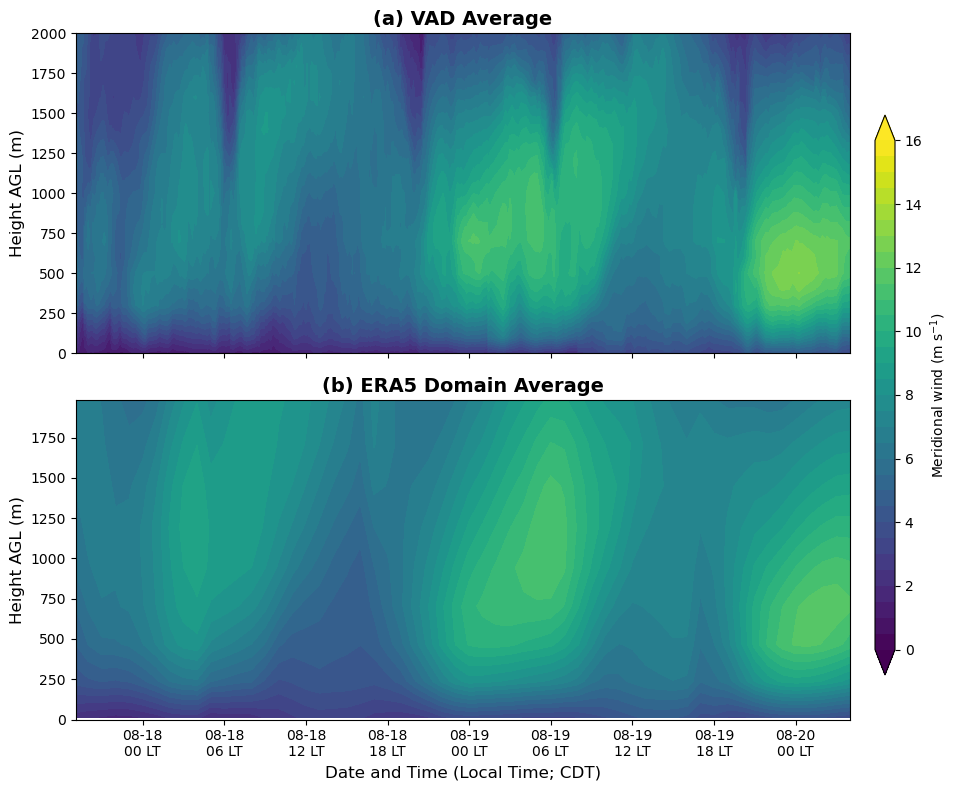

In [ ]:

 
# Time range in UTC for filtering
 
t_start = np.datetime64("2007-08-18T00:00:00")
t_end   = np.datetime64("2007-08-20T12:00:00")

 
# VAD Average Data
 
vad_times_np = np.array(common_times, dtype="datetime64[ns]")
time_mask_vad = (vad_times_np >= t_start) & (vad_times_np <= t_end)

vdata_plot = vad_avg[time_mask_vad, :]
plot_times_vad = mdates.date2num(to_local_time64(vad_times_np[time_mask_vad]))
height_vad = h_common

 
# ERA5 Domain Average
 
mask_era = (time_dt64 >= t_start) & (time_dt64 <= t_end)
v_plot_era = v_mean[mask_era, :]
time_plot_era = time_dt64[mask_era]
plot_times_era = mdates.date2num(to_local_time64(time_plot_era))
height_era = height_per_level

 
# Create 2x1 figure
 
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
all_cfs = []

 
# Top: VAD Average
 
cf1 = axes[0].contourf(plot_times_vad, height_vad, vdata_plot.T,
                        levels=np.linspace(0, 16, 33),
                        cmap="viridis", extend="both", rasterized=True)
axes[0].set_title("(a) VAD Average", fontsize=14, fontweight="bold")
axes[0].set_ylim(0, np.nanmax(height_vad))
axes[0].xaxis_date()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H LT"))
axes[0].set_ylabel("Height AGL (m)", fontsize=12)
all_cfs.append(cf1)

 
# Bottom: ERA5 Domain Average
 
cf2 = axes[1].contourf(plot_times_era, height_era, v_plot_era.T,
                        levels=np.linspace(0, 16, 33),
                        cmap="viridis", extend="both", rasterized=True)
axes[1].set_title("(b) ERA5 Domain Average", fontsize=14, fontweight="bold")
axes[1].set_ylim(0, np.nanmax(height_era))
axes[1].xaxis_date()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H LT"))
axes[1].set_xlabel("Date and Time (Local Time; CDT)", fontsize=12)
axes[1].set_ylabel("Height AGL (m)", fontsize=12)
all_cfs.append(cf2)

 
# Shared colorbar
 
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(all_cfs[0], cax=cbar_ax, label="Meridional wind (m s$^{-1}$)")

 
# Layout
 
plt.tight_layout(rect=[0.05, 0, 0.92, 1])
plt.savefig("VAD_ERA5_avg_comparison.png", dpi=400)
plt.show()


/scratch/colinwelty/tmp/ipykernel_2922902/605496655.py:44: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(plot_times, hdata, vdata_plot.T,
/scratch/colinwelty/tmp/ipykernel_2922902/605496655.py:72: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(plot_times, height_plot, v_plot.T,
/scratch/colinwelty/tmp/ipykernel_2922902/605496655.py:103: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0, 0.92, 1])


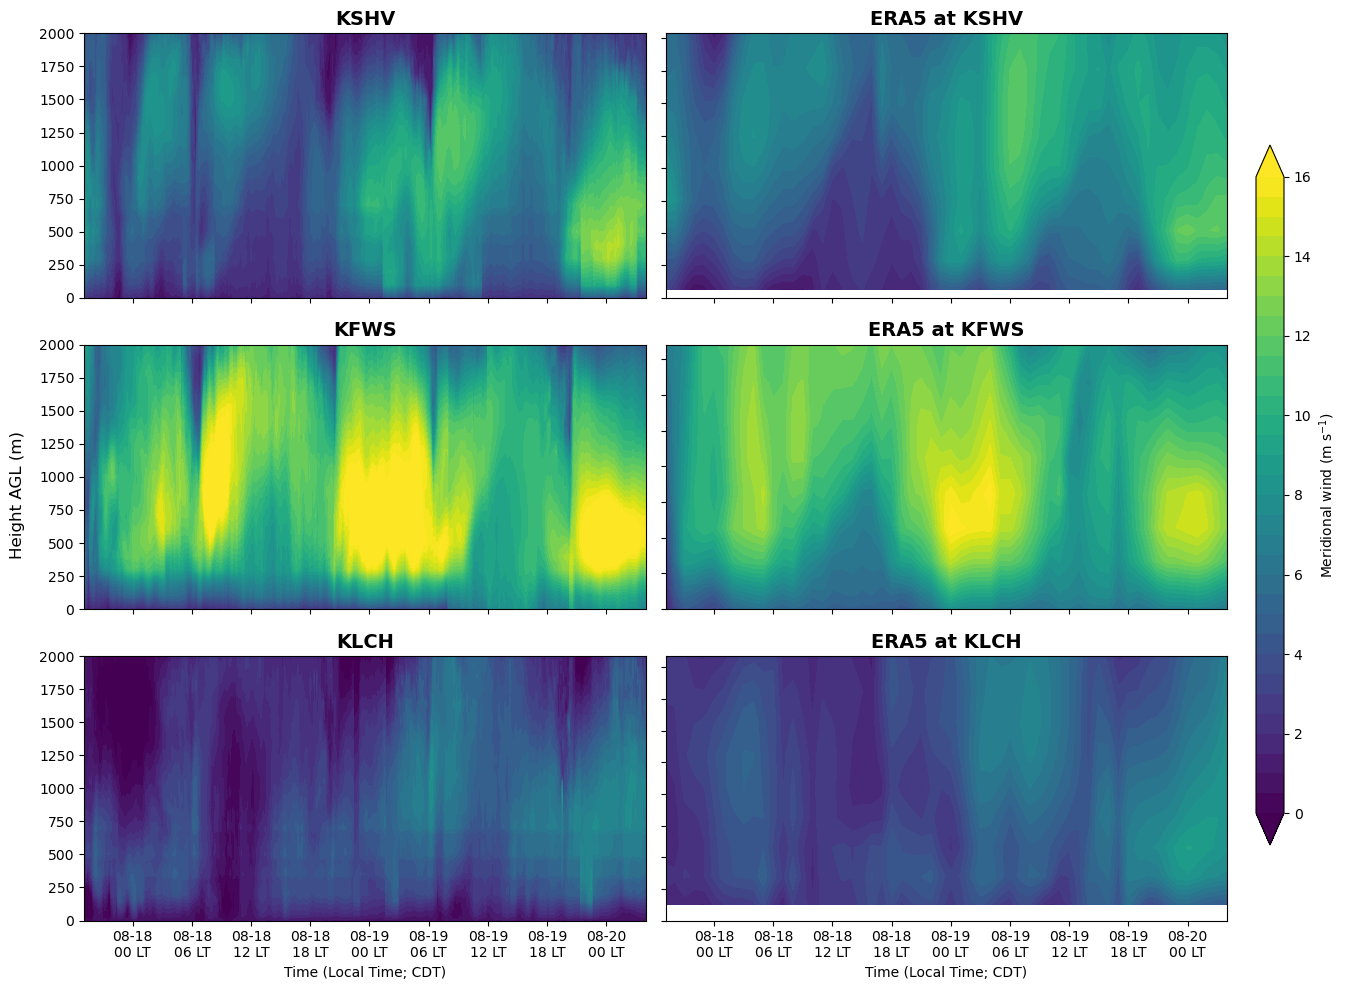

In [ ]:

 
# Time range in UTC for filtering
 
t_start = np.datetime64("2007-08-18T00:00:00")
t_end   = np.datetime64("2007-08-20T12:00:00")

 
# VAD Data
 
vad_names = ["KSHV", "KFWS", "KLCH"]
vads = [v_KSHV, v_KFWS, v_KLCH]
heights_vad = [h_KSHV, h_KFWS, h_KLCH]
times_vad_list = [rounded_times_KSHV, rounded_times_KFWS, rounded_times_KLCH]

# Convert to np.datetime64
times_vad_np_list = [np.array(times, dtype='datetime64[ns]') for times in times_vad_list]

 
# ERA5 Subset
 
radar_sites = {
    "KSHV": (32.45, -93.83),
    "KFWS": (32.57, -97.30),
    "KLCH": (30.13, -93.23),
}

lat_sub = lat[lat_inds]
lon_sub = lon[lon_inds]

 
# Create 3x2 figure
 
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
all_cfs = []  # to store contourf handles for shared colorbar

 
# Left column: VADs
 
for ax, vdata, hdata, times_np, name in zip(axes[:, 0], vads, heights_vad, times_vad_np_list, vad_names):
    time_mask = (times_np >= t_start) & (times_np <= t_end)
    vdata_plot = vdata[time_mask, :]
    plot_times = mdates.date2num(to_local_time64(times_np[time_mask]))
    
    cf = ax.contourf(plot_times, hdata, vdata_plot.T,
                     levels=np.linspace(0, 16, 33),
                     cmap="viridis",
                     extend="both", rasterized=True)
    
    ax.set_title(name, fontsize=14, fontweight="bold")
    ax.set_ylim(0, np.nanmax(hdata))
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H LT"))
    
    all_cfs.append(cf)

 
# Right column: ERA5 at radar sites
 
for ax, (radar, coords) in zip(axes[:, 1], radar_sites.items()):
    rlat, rlon = coords
    ilat, ilon = nearest_gridpoint(rlat, rlon, lat_sub, lon_sub)
    v_site = v_sub[:, :, ilat, ilon]       # (time, level)
    Z_site = Z_agl[:, :, ilat, ilon]       # (time, level)
    height_plot = np.nanmean(Z_site, axis=0)
    
    # Ensure mask matches v_site time dimension
    time_indices = np.where((time_dt64 >= t_start) & (time_dt64 <= t_end))[0]
    v_plot = v_site[time_indices, :]
    time_plot = time_dt64[time_indices]
    plot_times = mdates.date2num(to_local_time64(time_plot))

    cf = ax.contourf(plot_times, height_plot, v_plot.T,
                     levels=np.linspace(0, 16, 33), cmap="viridis", extend="both", rasterized=True)
    ax.set_title(f"ERA5 at {radar}", fontsize=14, fontweight="bold")
    ax.set_ylim(0, np.nanmax(height_plot))
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d\n%H LT"))

    all_cfs.append(cf)

 
# Final adjustments: shared colorbar & y-label
 
# Remove individual y-axis labels
for ax in axes[:, 0]:
    ax.set_ylabel("")  # left column ticks stay
for ax in axes[:, 1]:
    ax.set_ylabel("")  # right column no label
    ax.set_yticklabels([])  # remove tick numbers

# Shared left y-axis label
fig.text(0.04, 0.5, "Height AGL (m)", va='center', rotation='vertical', fontsize=12)

# Set x-axis labels only on bottom row
axes[-1, 0].set_xlabel("Time (Local Time; CDT)")
axes[-1, 1].set_xlabel("Time (Local Time; CDT)")

# Single colorbar to the right
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
fig.colorbar(all_cfs[0], cax=cbar_ax, label="Meridional wind (m s$^{-1}$)")

# Layout
plt.tight_layout(rect=[0.05, 0, 0.92, 1])
plt.savefig("VAD_ERA5_comparison_new.png", dpi=600)
plt.show()


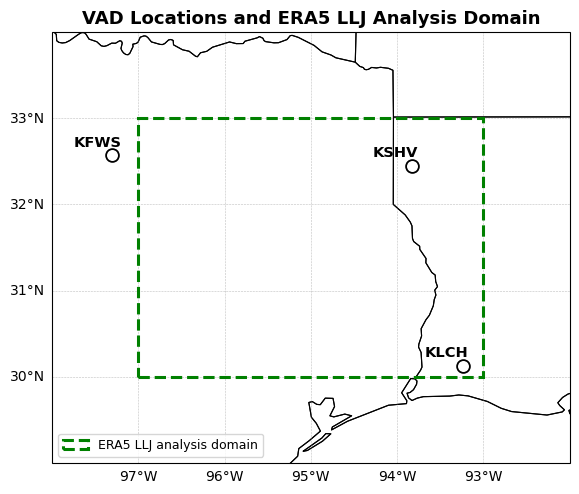

In [31]:

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches

# Larger plotting domain: one extra degree around requested LLJ box
plot_extent = [-98, -92, 29, 34]  # lon_min, lon_max, lat_min, lat_max

# ERA5 LLJ analysis/averaging box
llj_box = [-97, -93, 30, 33]  # lon_min, lon_max, lat_min, lat_max

radar_sites_map = {
    "KSHV": (32.45, -93.83),
    "KFWS": (32.57, -97.30),
    "KLCH": (30.13, -93.23),
}

fig = plt.figure(figsize=(7.2, 5.6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent(plot_extent, crs=ccrs.PlateCarree())

ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.8, edgecolor="black")
ax.add_feature(cfeature.COASTLINE.with_scale("50m"), linewidth=0.8)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.5)

# ERA5 LLJ averaging domain outline
lon_min, lon_max, lat_min, lat_max = llj_box

llj_rect = mpatches.Rectangle(
    (lon_min, lat_min),
    lon_max - lon_min,
    lat_max - lat_min,
    linewidth=2.2,
    edgecolor="green",
    facecolor="none",
    linestyle="--",
    transform=ccrs.PlateCarree(),
    zorder=4,
    label="ERA5 LLJ analysis domain"
)

ax.add_patch(llj_rect)

# VAD radar locations
for name, (rlat, rlon) in radar_sites_map.items():
    ax.scatter(
        rlon, rlat,
        s=85,
        marker="o",
        facecolor="white",
        edgecolor="black",
        linewidth=1.3,
        transform=ccrs.PlateCarree(),
        zorder=5
    )

    ax.text(
        rlon - 0.45, rlat + 0.10,
        name,
        fontsize=10.5,
        fontweight="bold",
        transform=ccrs.PlateCarree(),
        zorder=6
    )

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

ax.legend(loc="lower left", frameon=True, fontsize=9)

ax.set_title(
    "VAD Locations and ERA5 LLJ Analysis Domain",
    fontsize=13,
    fontweight="bold"
)

plt.savefig(
    "SI_VAD_locations_ERA5_LLJ_domain.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()
